<a href="https://colab.research.google.com/github/deekshithnagavalli/CRIME-PREDICTION-ML/blob/main/Crime_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("/content/NYPD_Complaint_Data_Current__Year_To_Date_.csv")
df.head()

,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,...,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column
0,298784667,114,QUEENS,12/09/2024,04:37:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,1016307.0,227998.0,40.792430,-73.884228,"(40.79243, -73.884228)",POINT (-73.884228 40.79243)
1,308328240,41,BRONX,06/18/2025,16:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,1017940.0,232184.0,40.803914,-73.878308,"(40.803914, -73.878308)",POINT (-73.878308 40.803914)
2,314788366,40,BRONX,10/17/2025,22:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,18-24,BLACK HISPANIC,F,1005028.0,234516.0,40.810352,-73.924942,"(40.8103518634571, -73.924942325642)",POINT (-73.924942325642 40.8103518634571)
3,307568863,41,BRONX,03/24/2025,01:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,18-24,WHITE,F,1013037.0,236657.0,40.816206,-73.896001,"(40.8162058439227, -73.8960011932583)",POINT (-73.8960011932583 40.8162058439227)
4,311408135H1,42,BRONX,08/18/2025,22:34:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,25-44,BLACK,M,1009748.0,240283.0,40.826169,-73.907868,"(40.826169, -73.907868)",POINT (-73.907868 40.826169)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466134 entries, 0 to 466133
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CMPLNT_NUM                466134 non-null  object 
 1   ADDR_PCT_CD               466134 non-null  int64  
 2   BORO_NM                   466134 non-null  object 
 3   CMPLNT_FR_DT              466134 non-null  object 
 4   CMPLNT_FR_TM              466134 non-null  object 
 5   CMPLNT_TO_DT              453403 non-null  object 
 6   CMPLNT_TO_TM              466134 non-null  object 
 7   CRM_ATPT_CPTD_CD          466134 non-null  object 
 8   HADEVELOPT                466134 non-null  object 
 9   HOUSING_PSA               30684 non-null   float64
 10  JURISDICTION_CODE         466133 non-null  float64
 11  JURIS_DESC                466133 non-null  object 
 12  KY_CD                     466133 non-null  float64
 13  LAW_CAT_CD                466133 non-null  o

In [7]:
print("Shape:", df.shape)
df.info()

Shape: (466134, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466134 entries, 0 to 466133
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CMPLNT_NUM                466134 non-null  object 
 1   ADDR_PCT_CD               466134 non-null  int64  
 2   BORO_NM                   466134 non-null  object 
 3   CMPLNT_FR_DT              466134 non-null  object 
 4   CMPLNT_FR_TM              466134 non-null  object 
 5   CMPLNT_TO_DT              453403 non-null  object 
 6   CMPLNT_TO_TM              466134 non-null  object 
 7   CRM_ATPT_CPTD_CD          466134 non-null  object 
 8   HADEVELOPT                466134 non-null  object 
 9   HOUSING_PSA               30684 non-null   float64
 10  JURISDICTION_CODE         466133 non-null  float64
 11  JURIS_DESC                466133 non-null  object 
 12  KY_CD                     466133 non-null  float64
 13  LAW_CAT_CD              

In [8]:
df.describe()

,ADDR_PCT_CD,HOUSING_PSA,JURISDICTION_CODE,KY_CD,PD_CD,TRANSIT_DISTRICT,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,466134.000000,30684.000000,466133.000000,466133.000000,465906.000000,30122.000000,4.661330e+05,466133.000000,466133.000000,466133.000000
mean,68.112178,8565.382838,0.573810,304.383532,430.861846,17.920424,1.003565e+06,197690.094190,40.709247,-73.930294
std,37.422533,19383.419848,4.804237,159.087667,232.203901,13.469614,2.310293e+04,24057.706616,0.066041,0.082788
min,1.000000,218.000000,0.000000,101.000000,100.000000,1.000000,-7.400000e+01,121174.000000,40.499026,-74.254439
25%,32.000000,450.000000,0.000000,118.000000,259.000000,3.000000,9.889740e+05,181646.000000,40.665207,-73.982950
50%,73.000000,645.000000,0.000000,341.000000,397.000000,20.000000,1.000622e+06,197523.000000,40.708786,-73.940966
75%,104.000000,1269.000000,0.000000,351.000000,638.000000,32.000000,1.015848e+06,215061.000000,40.756978,-73.885957
max,123.000000,74007.000000,97.000000,678.000000,922.000000,34.000000,1.067185e+06,259208.000000,40.878082,-73.700719


In [9]:
df.isnull().sum()

,0
CMPLNT_NUM,0
ADDR_PCT_CD,0
BORO_NM,0
CMPLNT_FR_DT,0
CMPLNT_FR_TM,0
CMPLNT_TO_DT,12731
CMPLNT_TO_TM,0
CRM_ATPT_CPTD_CD,0
HADEVELOPT,0
HOUSING_PSA,435450


                    1 Most Common Crime Types


**Problem Statement:**
What are the most frequently occurring crime types in the dataset?

**Result:**
Top crime categories are identified based on frequency.

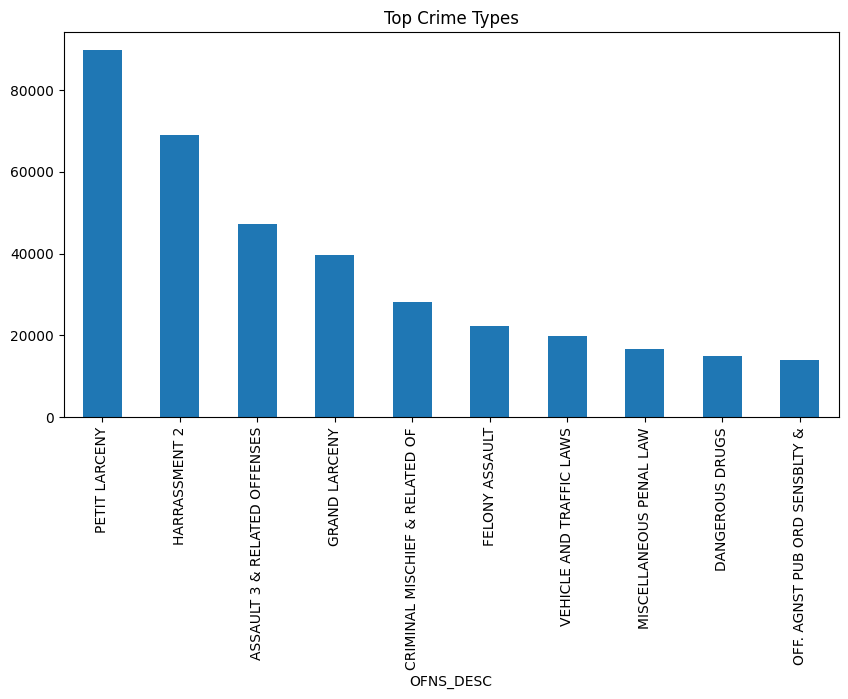

In [10]:
plt.figure(figsize=(10,5))
df['OFNS_DESC'].value_counts().head(10).plot(kind='bar')
plt.title("Top Crime Types")
plt.show()

In [11]:
df = df.dropna()

In [50]:
complaints_per_borough = df['BORO_NM'].value_counts()
average_complaints = complaints_per_borough.mean()

print(f"Average number of complaints per borough: {average_complaints:.2f}")

Average number of complaints per borough: 96593.50


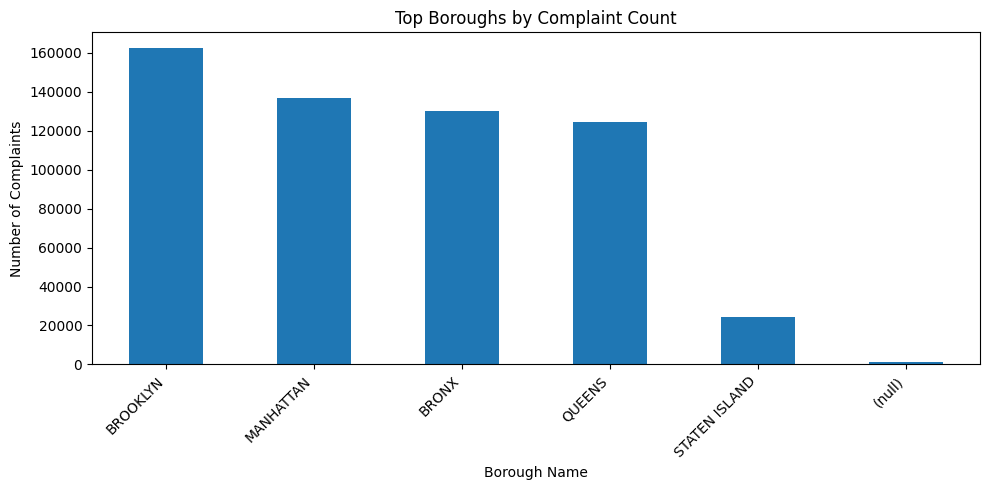

In [37]:
plt.figure(figsize=(10,5))
df['BORO_NM'].value_counts().head(10).plot(kind='bar')
plt.title("Top Boroughs by Complaint Count")
plt.xlabel("Borough Name")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribution of Top Crimes for a Specific Age Group

Let's visualize the top crimes for a selected age group. You can change the `selected_age_group` variable to explore other age demographics.

In [43]:
print("Available Victim Age Groups:")
print(valid_age_groups)

Available Victim Age Groups:
['18-24' '25-44' '<18' '65+' '45-64' '936' '945' '939' '-962' '-15' '-968'
 '942' '-967' '978' '983' '-1' '-2' '937' '-954' '951' '949' '-972' '-958']


In [44]:
valid_age_ranges = ['<18', '18-24', '25-44', '45-64', '65+']

# Filter the DataFrame to include only valid age ranges
df_filtered_age = df[df['VIC_AGE_GROUP'].isin(valid_age_ranges)].copy()

# Recalculate age_group_crime_counts and valid_age_groups with the filtered data
age_group_crime_counts = df_filtered_age.groupby(['VIC_AGE_GROUP', 'OFNS_DESC']).size().reset_index(name='Count')
age_group_crime_counts_filtered = age_group_crime_counts # No 'UNKNOWN' to filter at this stage as it's not in valid_age_ranges

valid_age_groups = age_group_crime_counts_filtered['VIC_AGE_GROUP'].unique()

print("Updated Available Victim Age Groups:")
print(valid_age_groups)

Updated Available Victim Age Groups:
['18-24' '25-44' '45-64' '65+' '<18']


### Comparative Analysis of Top Crimes Across All Valid Age Groups

Below are bar plots visualizing the top 5 most frequent crimes for each valid victim age group. This allows for a direct comparison of crime patterns across different demographics.

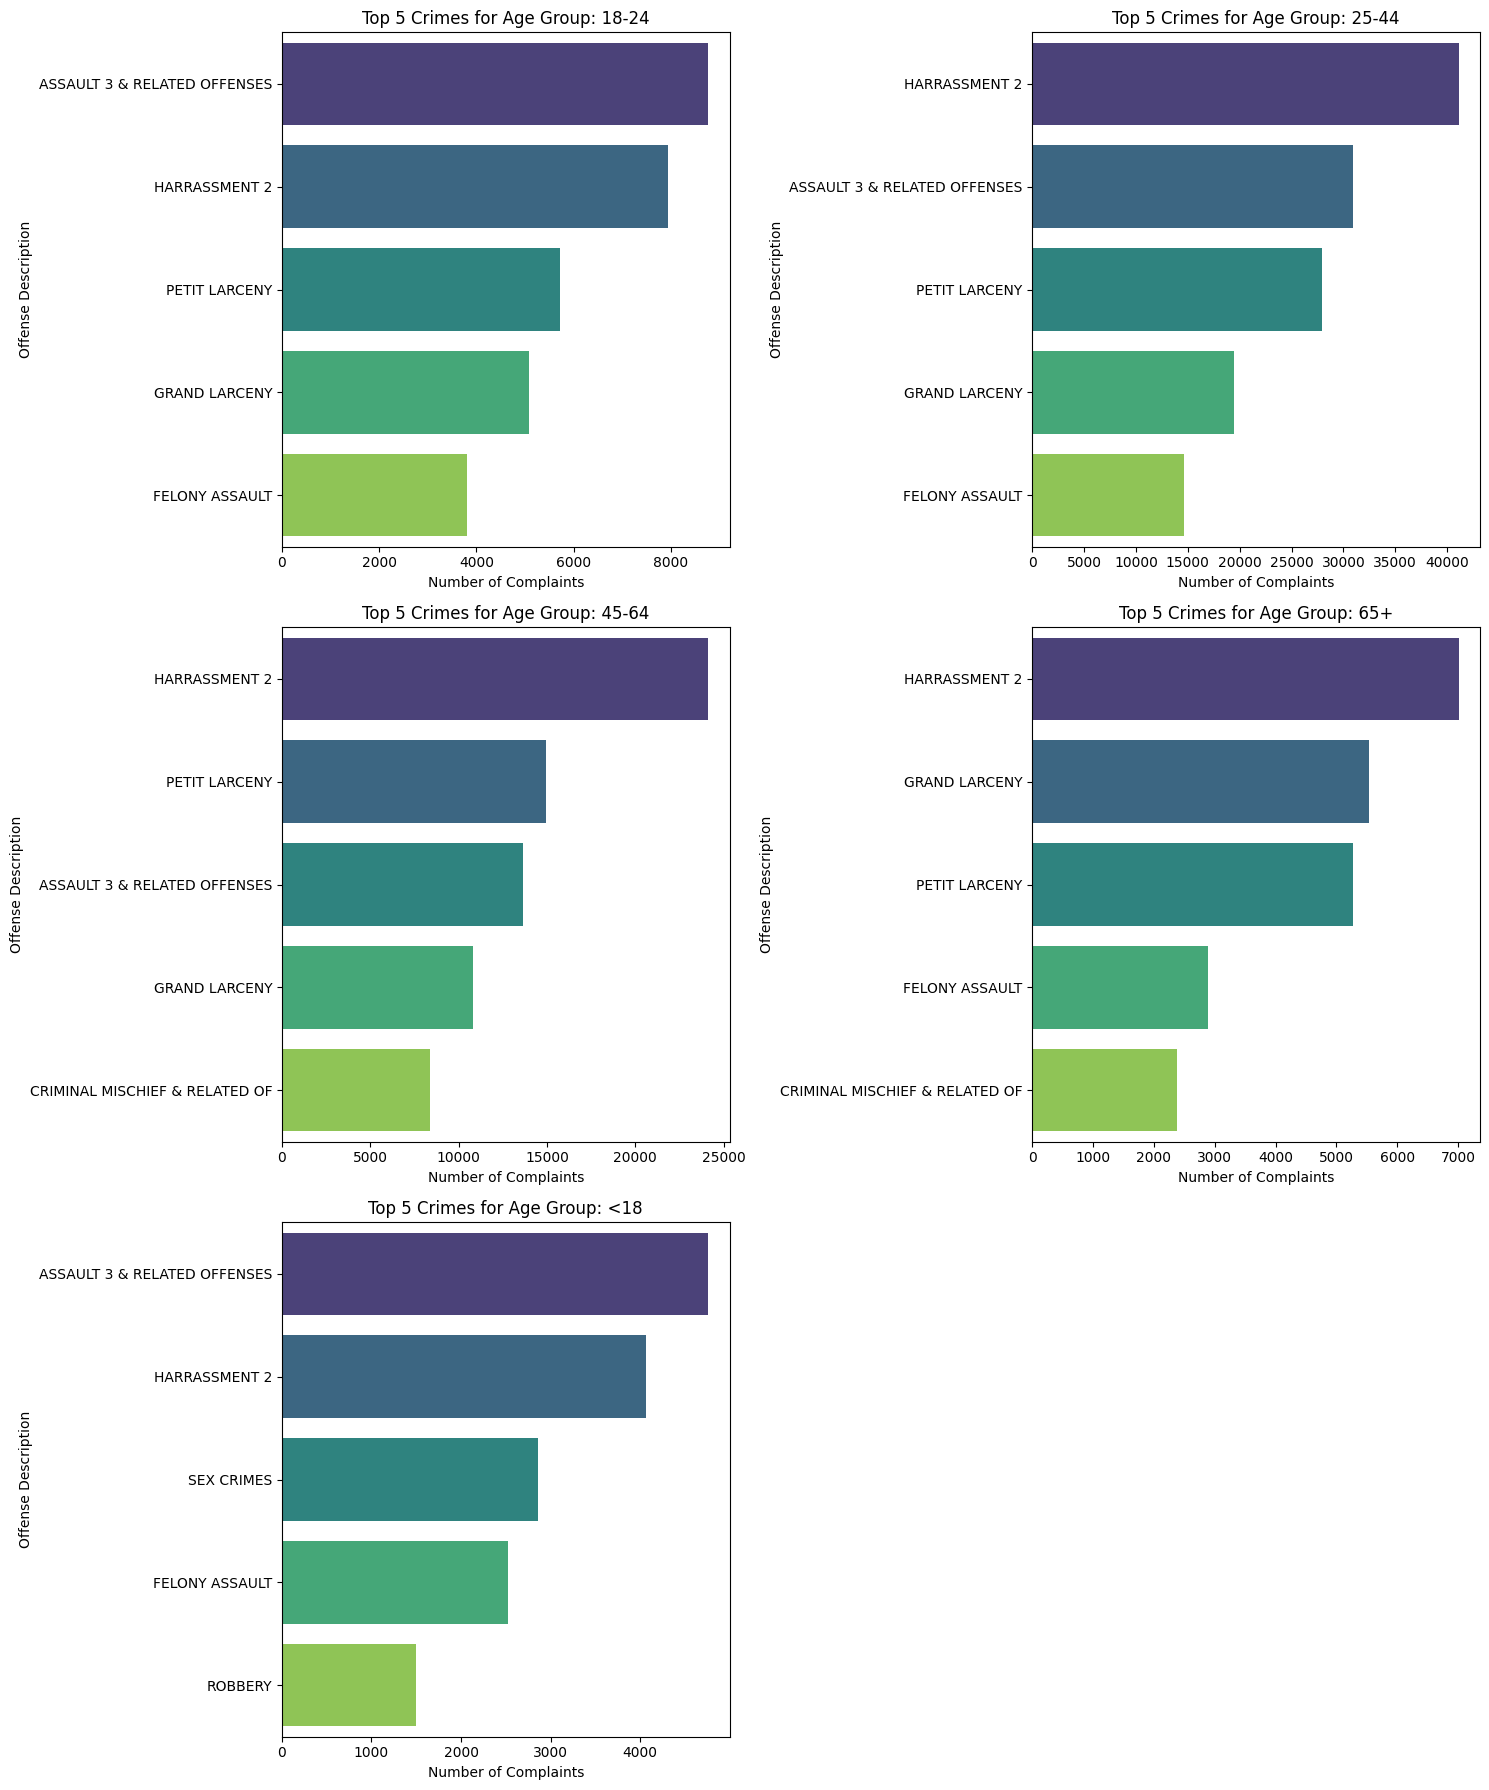

In [45]:
num_age_groups = len(valid_age_groups)
num_rows = (num_age_groups + 1) // 2  # Calculate number of rows needed (2 plots per row)
num_cols = 2

plt.figure(figsize=(15, 6 * num_rows))

for i, age_group in enumerate(valid_age_groups):
    plt.subplot(num_rows, num_cols, i + 1)
    top_crimes = age_group_crime_counts_filtered[age_group_crime_counts_filtered['VIC_AGE_GROUP'] == age_group].nlargest(5, 'Count')
    sns.barplot(x='Count', y='OFNS_DESC', data=top_crimes, palette='viridis', hue='OFNS_DESC', legend=False)
    plt.title(f'Top 5 Crimes for Age Group: {age_group}')
    plt.xlabel('Number of Complaints')
    plt.ylabel('Offense Description')
    plt.tight_layout()

plt.tight_layout()
plt.show()

### 3 Temporal Analysis of Crime Complaints

**Problem Statement:**
How do crime complaints vary over time (e.g., by day of week, by month, by hour)?

**Result:**
Identification of daily, weekly, and hourly patterns in crime occurrences.

In [49]:
# Convert date and time columns to datetime objects
df['CMPLNT_FR_DT'] = pd.to_datetime(df['CMPLNT_FR_DT'], errors='coerce')
df['CMPLNT_TO_DT'] = pd.to_datetime(df['CMPLNT_TO_DT'], errors='coerce')

# Extract temporal features
df['year'] = df['CMPLNT_FR_DT'].dt.year
df['month'] = df['CMPLNT_FR_DT'].dt.month
df['day_of_week'] = df['CMPLNT_FR_DT'].dt.dayofweek # Monday=0, Sunday=6
df['hour'] = pd.to_datetime(df['CMPLNT_FR_TM'], format='%H:%M:%S', errors='coerce').dt.hour

# Display basic stats for new temporal columns
print("Crime counts per year:")
print(df['year'].value_counts().sort_index())
print("\nCrime counts per month:")
print(df['month'].value_counts().sort_index())
print("\nCrime counts per day of week:")
print(df['day_of_week'].value_counts().sort_index())
print("\nCrime counts per hour:")
print(df['hour'].value_counts().sort_index())

Crime counts per year:
year
1963.0         1
1970.0         1
1975.0        11
1976.0         1
1978.0         1
1979.0         1
1980.0         5
1983.0         2
1984.0         2
1987.0         2
1988.0         4
1989.0         2
1990.0         2
1991.0         4
1992.0         5
1993.0         1
1994.0         3
1995.0         8
1996.0         2
1997.0         7
1998.0         1
1999.0         7
2000.0         7
2001.0        11
2002.0        23
2003.0         6
2004.0         8
2005.0        48
2006.0         8
2007.0         7
2008.0        18
2009.0         6
2010.0        20
2011.0        18
2012.0        13
2013.0        35
2014.0        45
2015.0       110
2016.0        69
2017.0        86
2018.0        95
2019.0       127
2020.0       203
2021.0       258
2022.0       488
2023.0      1026
2024.0      9074
2025.0    567668
Name: count, dtype: int64

Crime counts per month:
month
1.0     47007
2.0     42552
3.0     49280
4.0     49084
5.0     51384
6.0     49467
7.0     50597
8

### Analysis of Crime Complaints by Day of Week and Hour

The following plots visualize the distribution of crime complaints across the days of the week and hours of the day. This can help reveal consistent patterns in criminal activity.

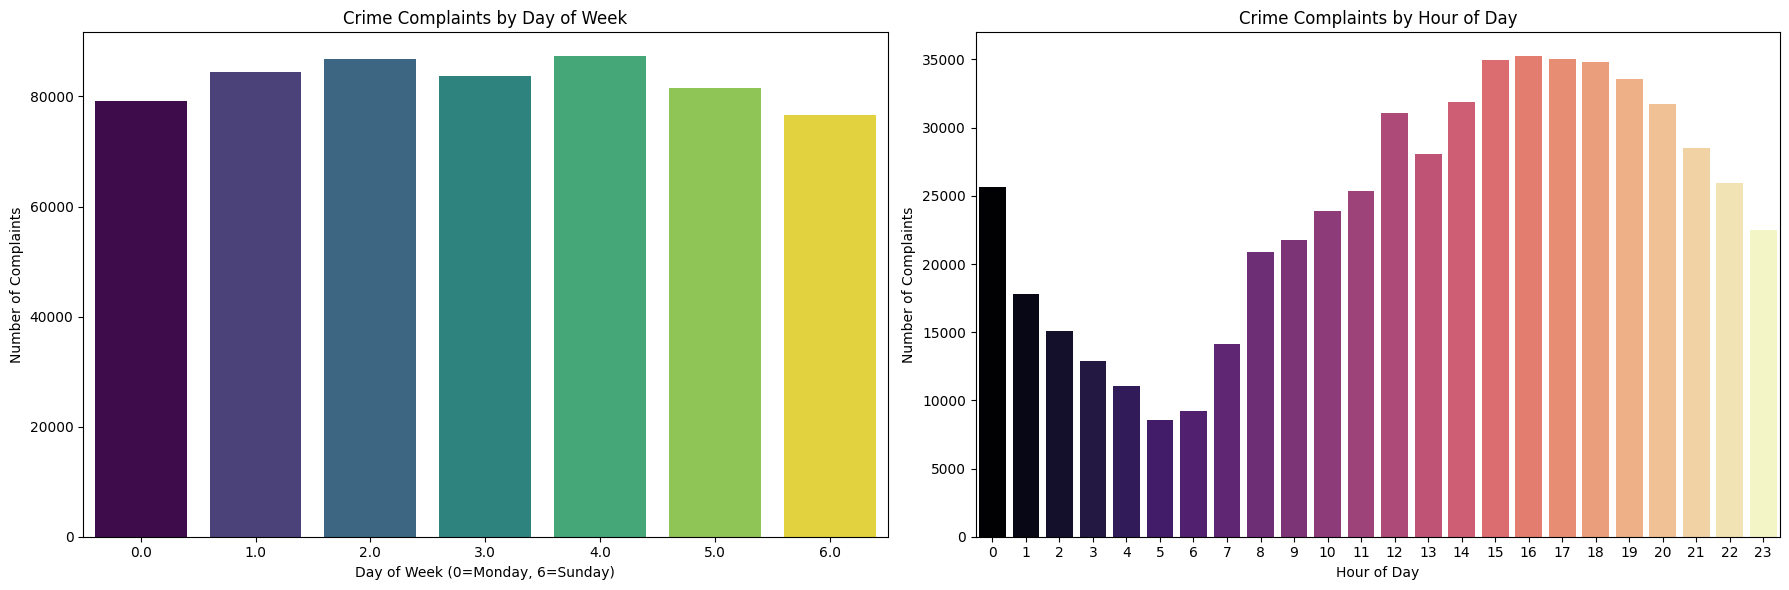

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot crimes by day of week
sns.countplot(x='day_of_week', data=df, palette='viridis', ax=axes[0], hue='day_of_week', legend=False)
axes[0].set_title('Crime Complaints by Day of Week')
axes[0].set_xlabel('Day of Week (0=Monday, 6=Sunday)')
axes[0].set_ylabel('Number of Complaints')

# Plot crimes by hour of day
sns.countplot(x='hour', data=df, palette='magma', ax=axes[1], hue='hour', legend=False)
axes[1].set_title('Crime Complaints by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Complaints')

plt.tight_layout()
plt.show()

## 4 Geographical Analysis of Crime Hotspots

**Problem Statement:**
Identify geographical areas with high crime density to understand urban safety and resource allocation.

**Result:**
Visual representation of crime hotspots across New York City.

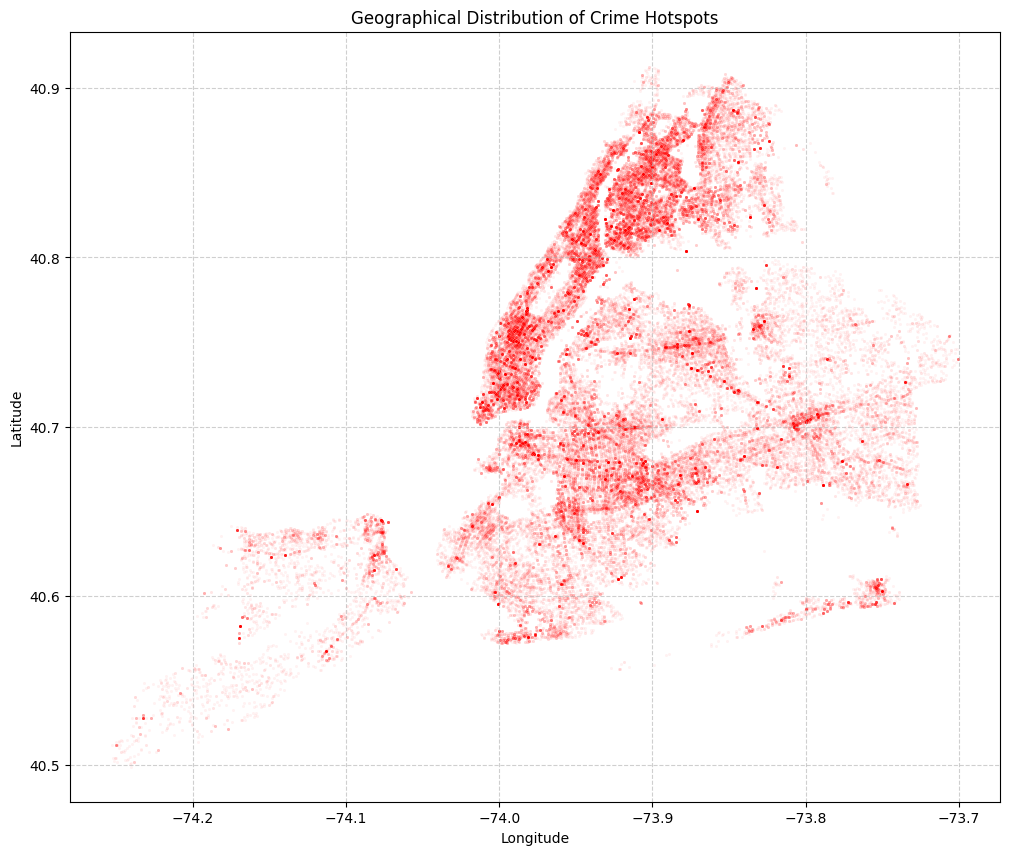

In [51]:
# Plotting crime hotspots using Latitude and Longitude
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='Longitude',
    y='Latitude',
    data=df.sample(n=100000, random_state=42), # Sample to avoid overplotting if dataset is too large
    alpha=0.05, # Use alpha to show density
    s=5, # Marker size
    color='red'
)
plt.title('Geographical Distribution of Crime Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The scatter plot above, with its transparent points, reveals areas where crime complaints are most concentrated. Denser, darker regions indicate higher crime activity, pinpointing potential hotspots across the city. This visualization can help in understanding where policing and community resources might be most needed.

### Crime Hotspots by Borough

To provide a more granular view of crime distribution, the following plots display crime hotspots for each individual borough. This allows for a detailed understanding of where resources might be most effectively deployed within each specific area.

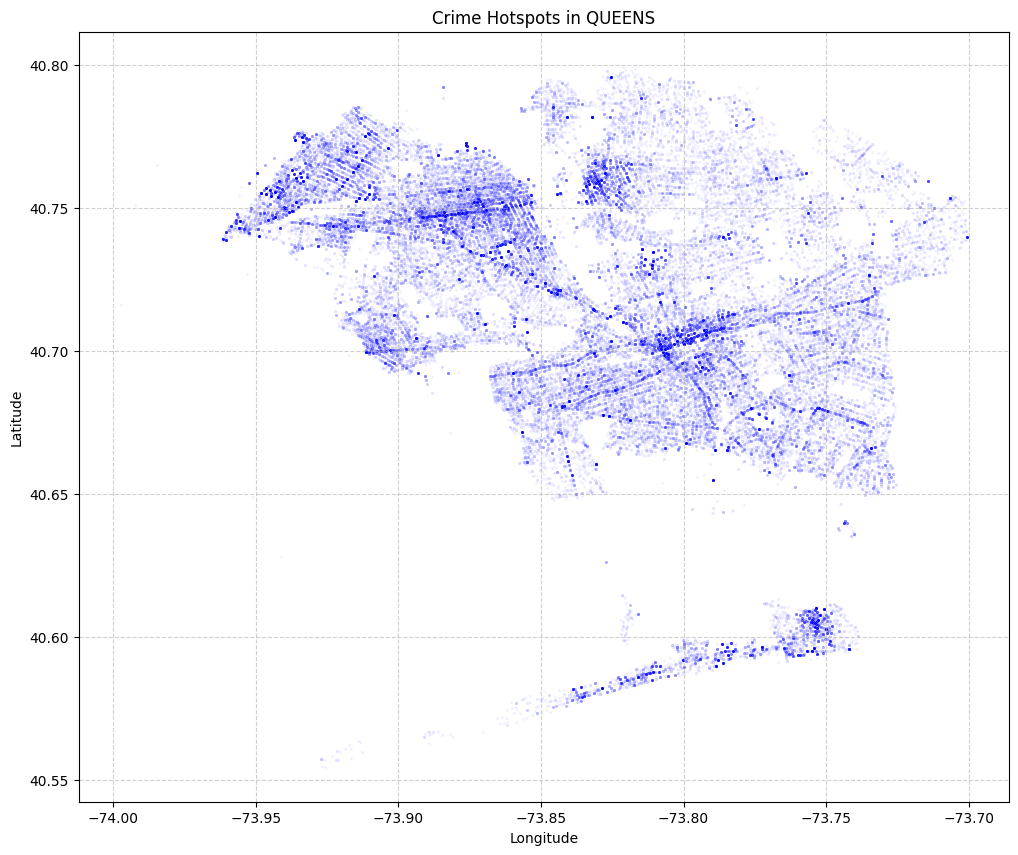

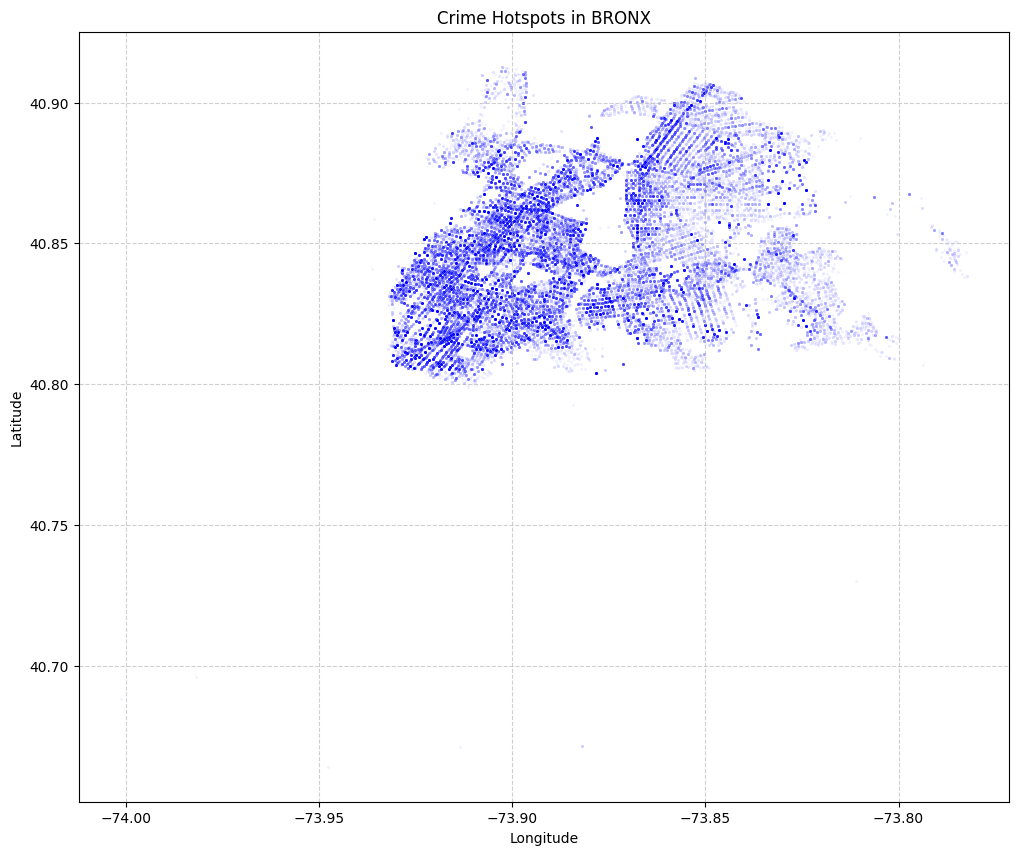

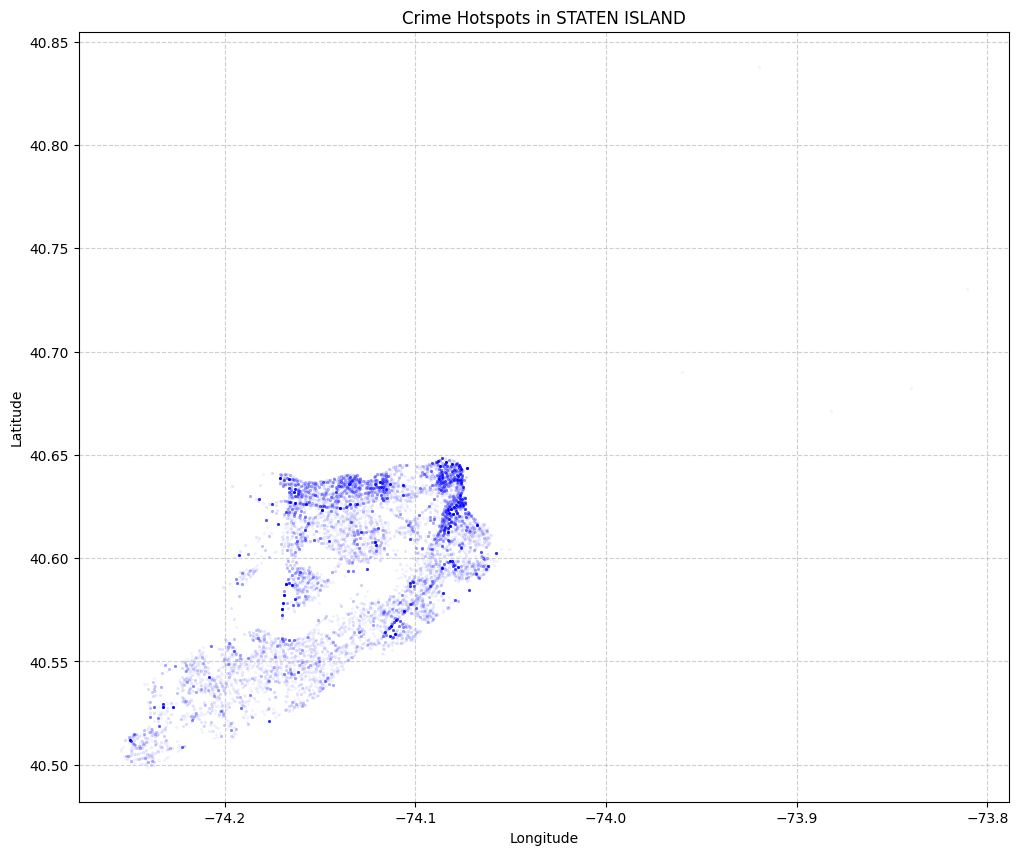

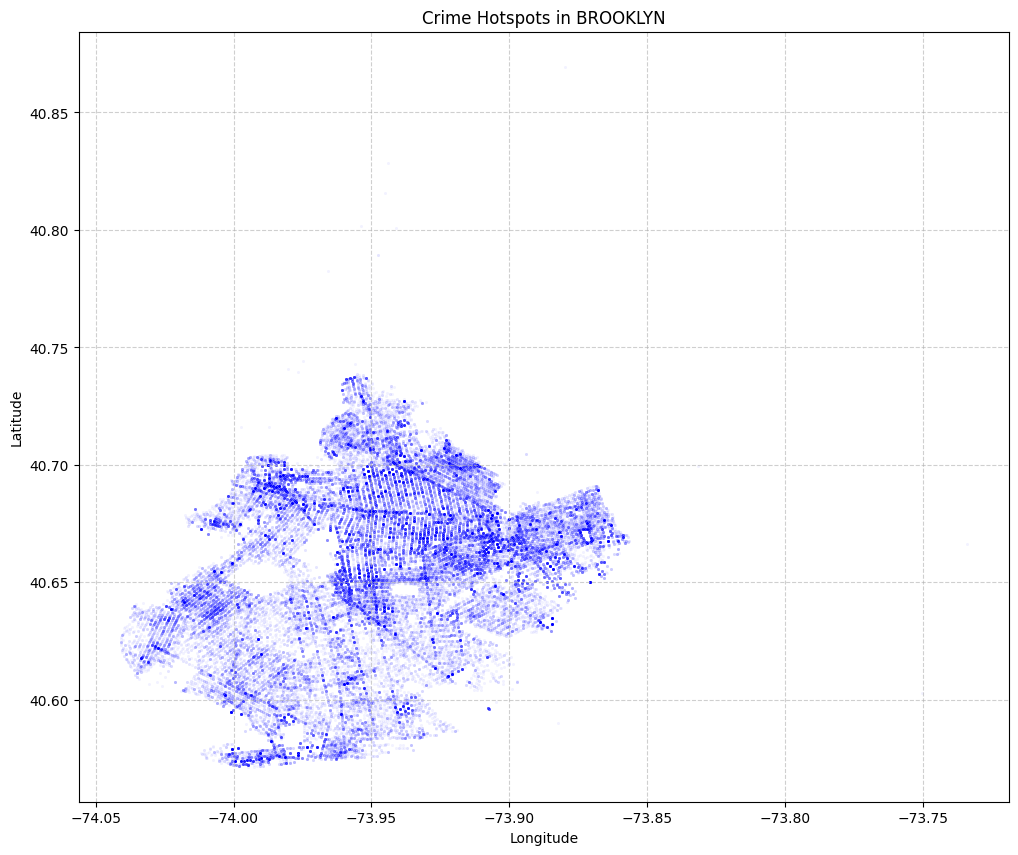

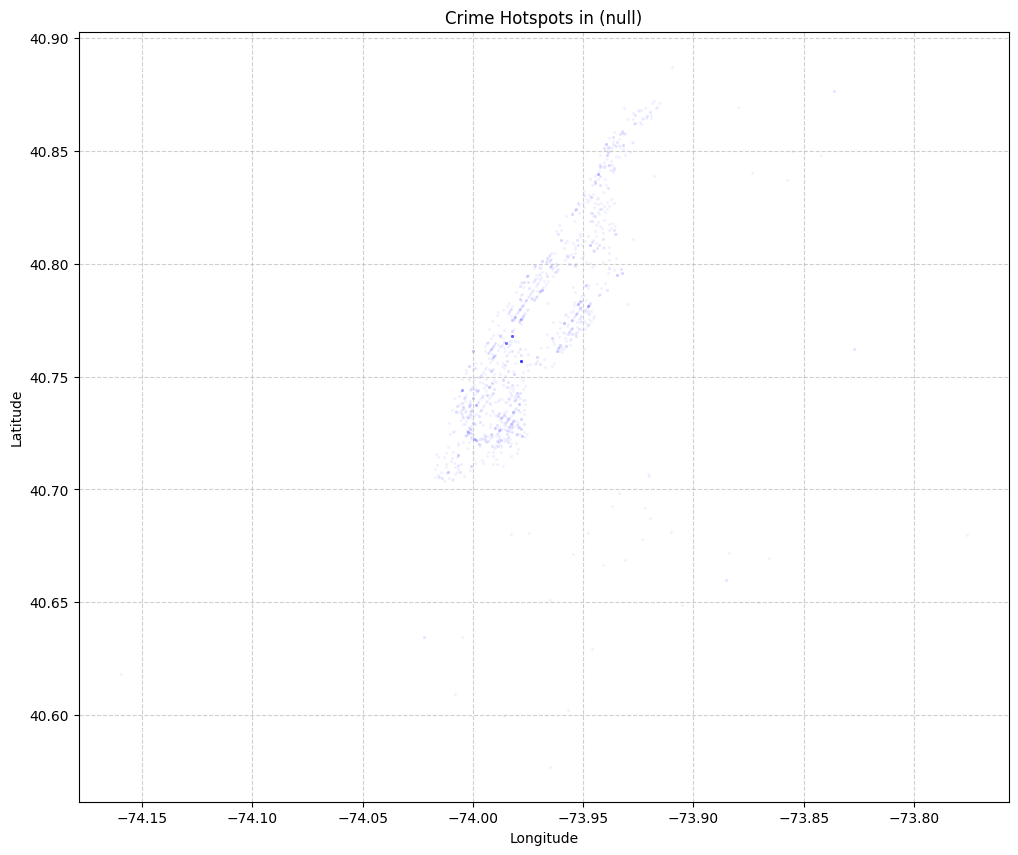

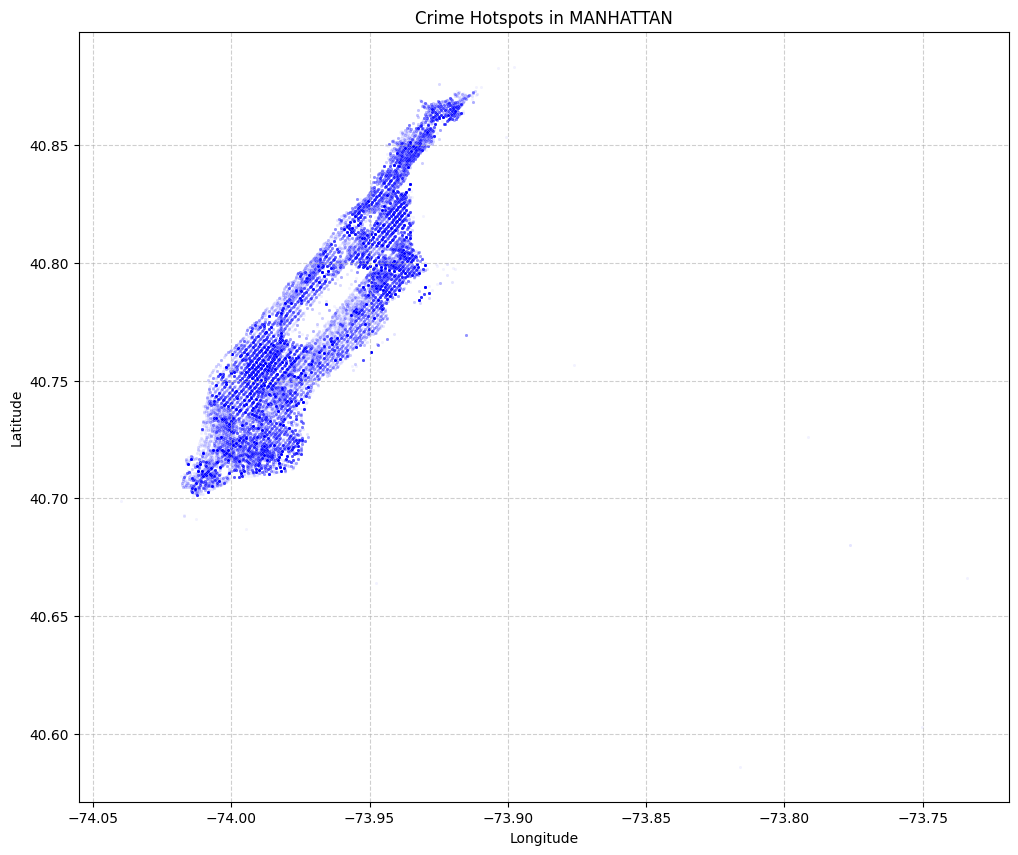

In [52]:
unique_boroughs = df['BORO_NM'].unique()

for borough in unique_boroughs:
    if pd.isna(borough): # Skip NaN boroughs
        continue

    borough_df = df[df['BORO_NM'] == borough]

    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='Longitude',
        y='Latitude',
        data=borough_df.sample(n=min(100000, len(borough_df)), random_state=42), # Sample to avoid overplotting
        alpha=0.05,
        s=5,
        color='blue'
    )
    plt.title(f'Crime Hotspots in {borough}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()